# Retail Demand Forecasting Using Machine Learning

## Tools Used
- Python
- Pandas
- Scikit-learn
- Matplotlib

## Models
- Linear Regression
- Gradient Boosting Regressor

## Evaluation Metric
- Mean Absolute Error (MAE)

This project forecasts retail sales demand using historical sales data and machine learning models. The goal is to identify trends, seasonality, and demand patterns to improve future sales predictions.

## Data Loading 

In [1]:
import pandas as pd

In [2]:
holidays = pd.read_csv('/Users/aaliyahgritly/Desktop/Bebo Stuff/Projects/Retail Demand Forecasting Project/data/holidays_events.csv')
oil = pd.read_csv('/Users/aaliyahgritly/Desktop/Bebo Stuff/Projects/Retail Demand Forecasting Project/data/oil.csv')
stores = pd.read_csv('/Users/aaliyahgritly/Desktop/Bebo Stuff/Projects/Retail Demand Forecasting Project/data/stores.csv')
train = pd.read_csv('/Users/aaliyahgritly/Desktop/Bebo Stuff/Projects/Retail Demand Forecasting Project/data/train.csv')

## EDA

In [3]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


* Convert date column to datetime to be able to extract day/month/year 
* Extract day/month/year

In [4]:
train['date'] = pd.to_datetime(train['date'])

In [5]:
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['day'] = train['date'].dt.day
train['day_of_week'] = train['date'].dt.day_name()

## Time Series Analysis

<Axes: title={'center': 'Daily Sales'}, xlabel='date'>

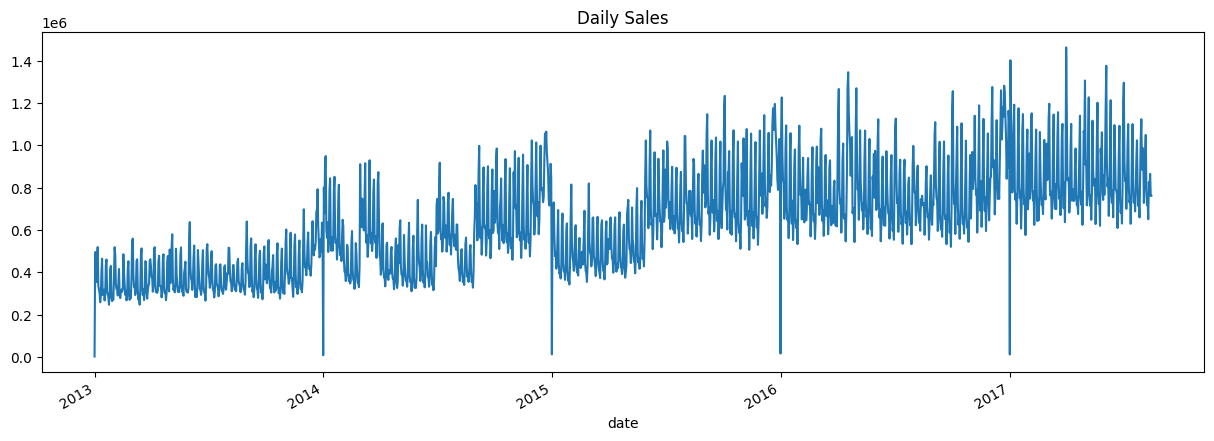

In [6]:
# Grouping sales by date
daily_sales = train.groupby('date')['sales'].sum()
# Plotting daily sales
daily_sales.plot(figsize = (15, 5), title = 'Daily Sales')

* Seems that sales are increasing year by year. That is an upward trend.

In [ ]:
# Plotting the first 30 days of sales
daily_sales.iloc[:30].plot(kind = 'bar', figsize = (15, 5), title = 'Daily Sales - First 30 Days')

<Axes: title={'center': 'Average Sales by Day of Week'}, xlabel='day_of_week'>

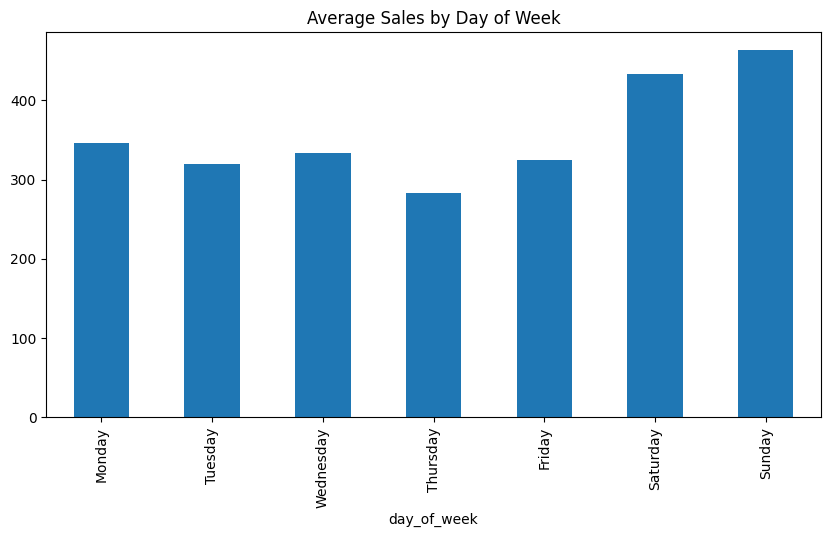

In [8]:
weekday_sales = train.groupby('day_of_week')['sales'].mean()

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] # Define the correct order of weekdays
weekday_sales = weekday_sales.reindex(weekday_order) # Reorder the series to match the defined order
weekday_sales.plot(kind='bar', figsize=(10, 5), title='Average Sales by Day of Week')

- So weekends are strongest sales day unsurprisingly, that is seasonality (cyclical purchasing behaviour)
* December also being highest sales month is a strong seasonal signal

* Trend - long term direction
* Seasonality - repeating patterns
* Noise - random fluctuations 
* Cycles - broader economic/business cycles

<Axes: title={'center': 'Monthly Average Sales'}, xlabel='month'>

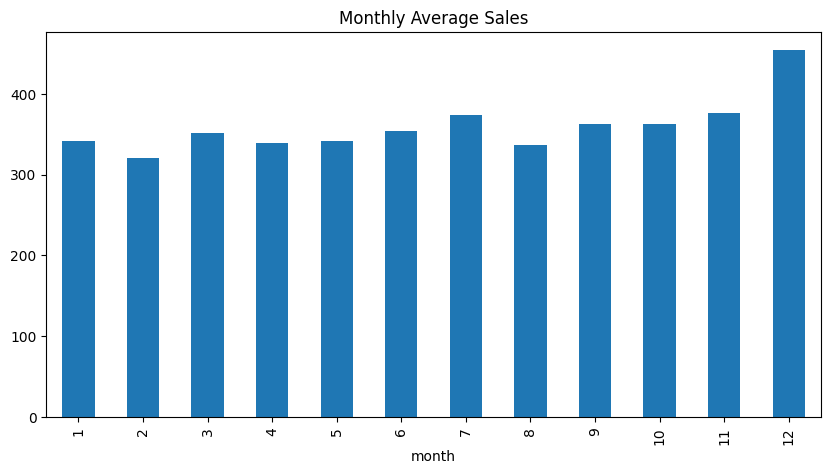

In [9]:
monthly_sales = train.groupby('month')['sales'].mean()

monthly_sales.plot(kind = 'bar', figsize = (10, 5), title = 'Monthly Average Sales')

# Create Lag Features
* Lag is using past sales to predict future sales, which forecasting heavily relies on.
* Rolling average gets the average sales over the last 7 days to smooth short-term fluctuations.

In [10]:
daily_sales = train.groupby('date')['sales'].sum().reset_index()

In [11]:
daily_sales['lag_1'] = daily_sales['sales'].shift(1) #Moving the sales column down by 1 row to create a lag of 1 day
daily_sales['lag_7'] = daily_sales['sales'].shift(7) # Get the sales from 7 days ago to capture weekly seasonality

In [12]:
# Calculate the rolling mean of sales over a 7-day window to capture trends and smooth out short-term fluctuations
daily_sales['rolling_mean_7'] = (daily_sales['sales'].rolling(window = 7).mean())

* Remove missing values

In [13]:
daily_sales = daily_sales.dropna() # Remove rows with NaN values resulting from lag and rolling mean calculations

In [14]:
daily_sales.head(10)

,date,sales,lag_1,lag_7,rolling_mean_7
7,2013-01-08,318347.777981,336122.801066,2511.618999,409075.632504
8,2013-01-09,302530.809018,318347.777981,496092.417944,381423.974086
9,2013-01-10,258982.003049,302530.809018,361461.231124,366784.084361
10,2013-01-11,289737.685085,258982.003049,354459.677093,357538.085502
11,2013-01-12,403258.212011,289737.685085,477350.121229,346953.527042
12,2013-01-13,464638.547998,403258.212011,519695.401088,339088.262315
13,2013-01-14,293348.362078,464638.547998,336122.801066,332977.628174
14,2013-01-15,299129.549954,293348.362078,318347.777981,330232.167027
15,2013-01-16,318347.913946,299129.549954,302530.809018,332491.753446
16,2013-01-17,267498.515975,318347.913946,258982.003049,333708.398150


* Lag 1 is sales of the previous day
* Lag 7 is sales of same day last week 
* Rolling mean 7 is average sales over the last week

## Build First Forecasting Model (Baseline Model - Linear Regression)
* In churn we wanted to predict 0 or 1, yes or no, but in sales forecasting we predict actual numbers.
* In forecasting you predict the future from the past, using older data for training, and newer data for testing.

1) Define Features & Target
2) Split the data 80% training and 20% testing
3) Get the Mean Absolute Error (MAE)
4) Visualize predictions 

In [15]:
y = daily_sales['sales'] # Target variable, the sales we want to predict

In [16]:
X = daily_sales[['lag_1', 'lag_7', 'rolling_mean_7']] 
# Features for the model, including lagged sales and rolling mean
# These are foundational features time forecasting features

In [17]:
split_index = int(len(daily_sales) * 0.8) # Calculate the index for an 80-20 train-test split (2013-2016 for training, 2017 for testing)

# Training & testing features
X_train = X[:split_index] 
X_test = X[split_index:] 

# Training & testing target variable
y_train = y[:split_index] 
y_test = y[split_index:] 

In [18]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression() # Initialize the linear regression model

model.fit(X_train, y_train) # Fit the model to the training data

# This model basically does today_sales = a(lag_1) + b(lag_7) + c(rolling_mean_7) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
predictions = model.predict(X_test) # Use the model to make predictions on the test set

In [20]:
from sklearn.metrics import mean_absolute_error 

mae = mean_absolute_error(y_test, predictions) # Calculate the Mean Absolute Error between actual and predicted sales

print(f'Mean Absolute Error: {mae}') # Print the MAE to evaluate the model's performance

Mean Absolute Error: 100177.66341534414


* mae = 100177.66 means the model is off by about 100177.66 sales on average
* Wether this number is good or bad depends on the scale of the data. In this case the sales value are around 700k to 1.2 million, so the error range is roughly 8-12%

In [21]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

results.reset_index(drop = True, inplace = True) # Reset the index of the results DataFrame for better visualization

results.head(10)

,Actual,Predicted
0,6.034279e+05,731929.227700
1,6.242621e+05,700666.134316
2,5.683248e+05,640056.066271
3,6.919126e+05,654761.387525
4,8.992193e+05,805859.300291
5,1.018663e+06,909634.437931
6,6.811593e+05,787815.361304
7,6.509803e+05,661889.587940
8,6.669284e+05,664746.891783
9,5.332763e+05,642190.486014


<Axes: title={'center': 'Actual vs Predicted Sales (LR 1.0)'}>

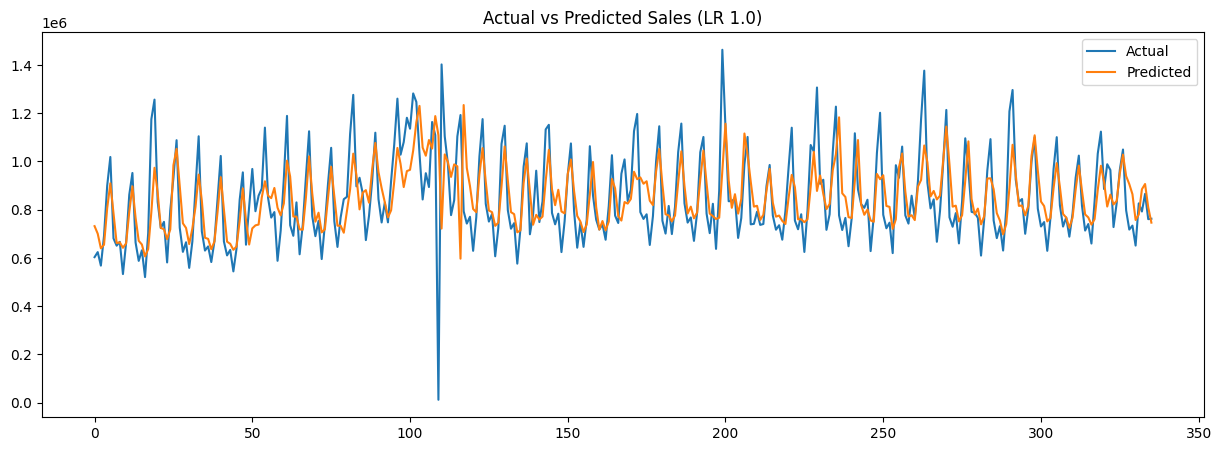

In [22]:
results[['Actual', 'Predicted']].plot(figsize = (15, 5), title = 'Actual vs Predicted Sales (LR 1.0)')

* The model learned trend, momentum, and weekly patterns
* The model seems to be prediciting stable patterns very well, but struggles with spikes (holidays, promotions, events, etc), due to it only knowing yeterday's sales (lag_1), last week's sales (lag_7), and rollling_mean_7 (rolling average past week)


## Improvements to Linear Regression Model
* Currently the model only knows previous sales but doesnt know months, weekends, holidays, or seasons

1) Add time-based features like to teach the model that weekends behave differenlty, holidays are different, etc

In [23]:
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek # Add a column for the day of the week (0=Monday, 6=Sunday)
daily_sales['month'] = daily_sales['date'].dt.month # Add a column for the month
daily_sales['year'] = daily_sales['date'].dt.year # Add a column for the year

In [24]:
X = daily_sales[['lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month', 'year']] # Update features to include new date-based features

In [25]:
# Retrain the model with the new features

split_index = int(len(daily_sales) * 0.8) #

X_train = X[:split_index] 
X_test = X[split_index:] 

y_train = y[:split_index] 
y_test = y[split_index:] 

In [26]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression() # Initialize the linear regression model

model.fit(X_train, y_train) # Fit the model to the training data

# This model basically does today_sales = a(lag_1) + b(lag_7) + c(rolling_mean_7) + d(day_of_week) + e(month) + f(year)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
predictions = model.predict(X_test)

In [28]:
mae = mean_absolute_error(y_test, predictions) 
print(f"Mean Absolute Error with new features: {mae}")

Mean Absolute Error with new features: 84362.01297542313


* Old MAE = 100,177 
* New MAE = 84,362

In [29]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

results.reset_index(drop = True, inplace = True) # Reset the index of the results DataFrame for better visualization
results.head(5)

,Actual,Predicted
0,603427.946974,665656.845219
1,624262.071976,657626.011719
2,568324.812986,664678.448357
3,691912.601466,688226.911282
4,899219.297508,824099.679755


<Axes: title={'center': 'Actual vs Predicted Sales (LR 2.0)'}>

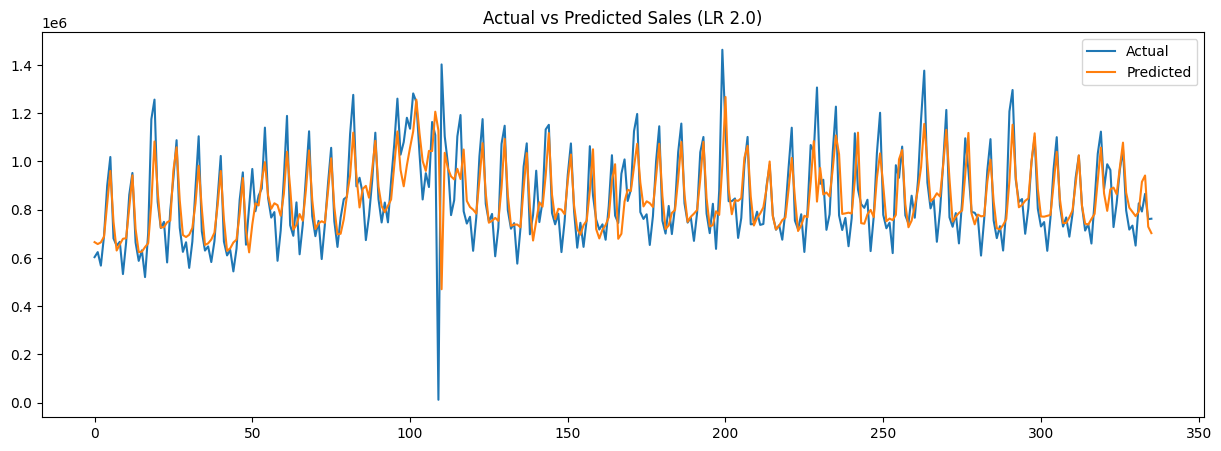

In [30]:
results[['Actual', 'Predicted']].plot(figsize = (15, 5), title = 'Actual vs Predicted Sales (LR 2.0)')

* The model improves noticeably as now it follows trends more closely
* Most normal days are predicted much better now, the model learned core demand behaviour

# Improve model further

* Add holiday features

In [31]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [32]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


* Convert date

In [33]:
holidays['date'] = pd.to_datetime(holidays['date']) # Convert the 'date' column to datetime format for easier manipulation

In [34]:
holidays['is_holiday'] = 1 # Create a new column to indicate that these dates are holidays

In [35]:
# Merge the holidays data with the daily_sales data to add the 'is_holiday' feature
# Any dates matching holidays will have 'is_holiday' set to 1, while non-holiday dates will have NaN 
daily_sales = daily_sales.merge(holidays[['date', 'is_holiday']], on = 'date', how = 'left')

In [36]:
daily_sales['is_holiday'] = daily_sales['is_holiday'].fillna(0) # Fill NaN values with 0 to indicate non-holiday dates

* Add `is_holiday` to the feature list and try again

In [37]:
X = daily_sales[['lag_1', 'lag_7', 'rolling_mean_7', 'day_of_week', 'month', 'year', 'is_holiday']] # Update features to include the 'is_holiday' feature

y = daily_sales['sales'] # Target variable, the sales we want to predict

In [38]:
# Retrain the model with the new features

split_index = int(len(daily_sales) * 0.8) #

X_train = X[:split_index] 
X_test = X[split_index:] 

y_train = y[:split_index] 
y_test = y[split_index:] 

In [39]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression() # Initialize the linear regression model

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
predictions = model.predict(X_test)

In [41]:
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error with holiday feature: {mae}")

Mean Absolute Error with holiday feature: 84245.0859539897


* Old MAE = 84,362
* New MAE = 84,245

In [42]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

results.reset_index(drop = True, inplace = True) # Reset the index of the results DataFrame for better visualization
results.sample(15)

,Actual,Predicted
182,7.543904e+05,8.568165e+05
183,7.009980e+05,7.197694e+05
92,7.471616e+05,8.142923e+05
82,1.113441e+06,9.399983e+05
304,1.100833e+06,1.114940e+06
144,8.346672e+05,8.122996e+05
32,8.906136e+05,8.254088e+05
150,6.243875e+05,8.003114e+05
143,7.488827e+05,8.310076e+05
125,1.175725e+06,1.074199e+06


<Axes: title={'center': 'Actual vs Predicted Sales (LR 3.0)'}>

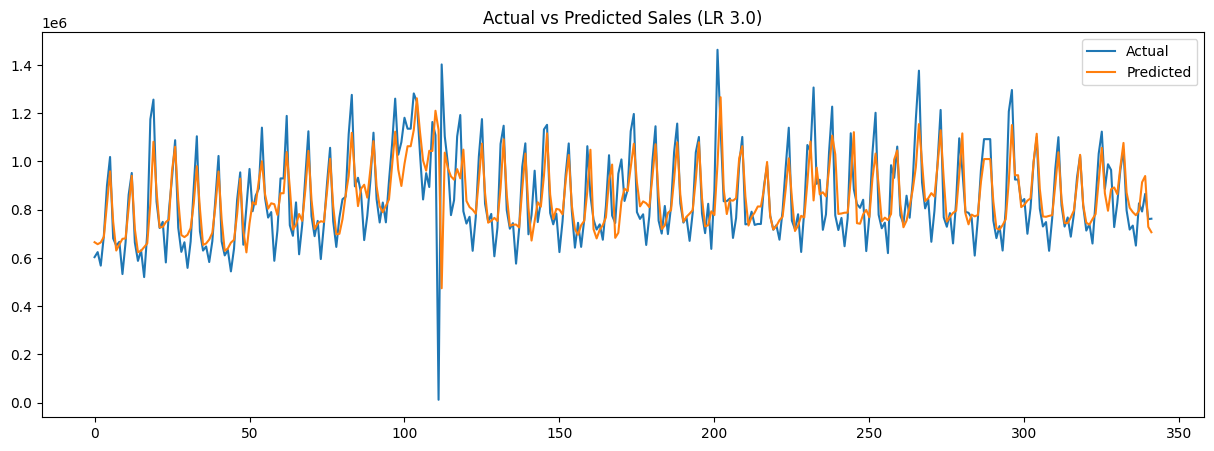

In [44]:
results[['Actual', 'Predicted']].plot(figsize = (15, 5), title = 'Actual vs Predicted Sales (LR 3.0)')

## Build a New Model (Advanced Model - Gradient Boosting)

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

# This is a more advanced model that can capture complex relationships in the data, often leading to better performance than linear regression for time series forecasting tasks
# n_estimators: number of boosting stages to perform
# learning_rate: how much the contribution of each tree is shrunk
# max_depth: maximum depth of the individual regression estimators, controlling the complexity of the model
# random_state: seed for reproducibility of results
gbr_model = GradientBoostingRegressor(
    n_estimators = 200, learning_rate = 0.05, max_depth = 5, random_state = 42
    )

gbr_model.fit(X_train, y_train)

gbr_predictions = gbr_model.predict(X_test)

In [46]:
gbr_mae = mean_absolute_error(y_test, gbr_predictions)

print(f"Mean Absolute Error with Gradient Boosting Regressor: {gbr_mae}")

Mean Absolute Error with Gradient Boosting Regressor: 71937.02567253042


* Old MAE = 84,245
* New MAE = 71,937
* Error reduction is about 14.6%

In [47]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions})

results.reset_index(drop = True, inplace = True) # Reset the index of the results DataFrame for better visualization
results.sample(15)

,Actual,Predicted
33,1.104505e+06,9.805510e+05
226,7.189961e+05,7.118068e+05
2,5.683248e+05,6.642857e+05
183,7.009980e+05,7.197694e+05
240,7.158112e+05,7.824143e+05
301,7.002720e+05,8.376939e+05
243,7.648124e+05,7.878706e+05
102,1.135849e+06,1.063216e+06
340,7.609224e+05,7.290528e+05
93,8.297632e+05,7.898911e+05


<Axes: title={'center': 'Actual vs Predicted Sales (XGBoost Model)'}>

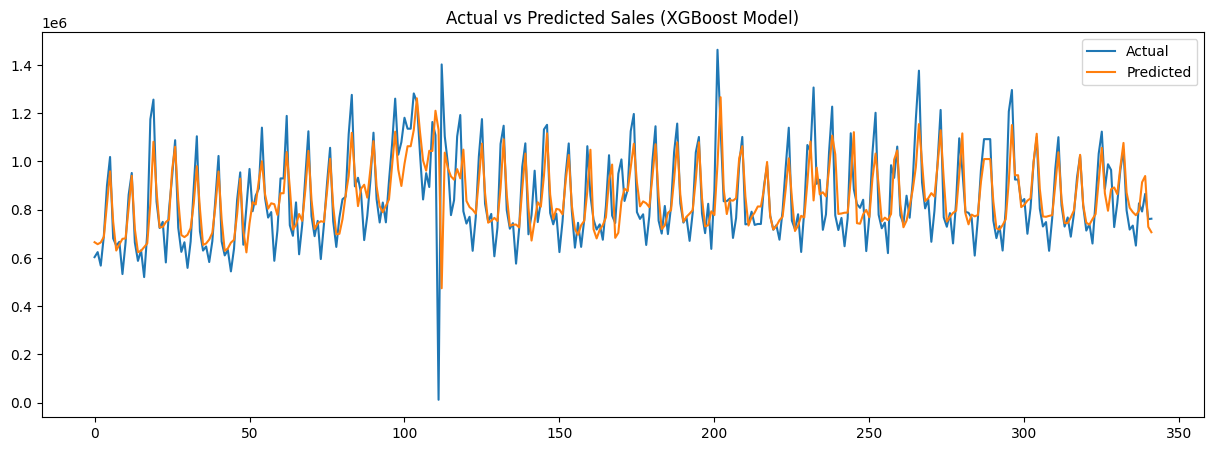

In [48]:
results[['Actual', 'Predicted']].plot(figsize = (15, 5), title = 'Actual vs Predicted Sales (XGBoost Model)')

# Adding `feature_importance`
* Gradient Boosting worked better becasue it learns more flexible patterns, nonlinear relationships, and feature interactions better than Linear Regression.
* `feature_importance` helps answer what drives demand the most

In [49]:
# Feature importance from the Gradient Boosting Regressor to understand which features are most influential in predicting sales
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': gbr_model.feature_importances_})

feature_importance = feature_importance.sort_values(by = 'Importance', ascending = False)

print(feature_importance)

          Feature  Importance
2  rolling_mean_7    0.493609
1           lag_7    0.206494
3     day_of_week    0.177292
0           lag_1    0.102611
4           month    0.010142
6      is_holiday    0.007111
5            year    0.002740


<Axes: title={'center': 'Feature Importance'}, xlabel='Feature'>

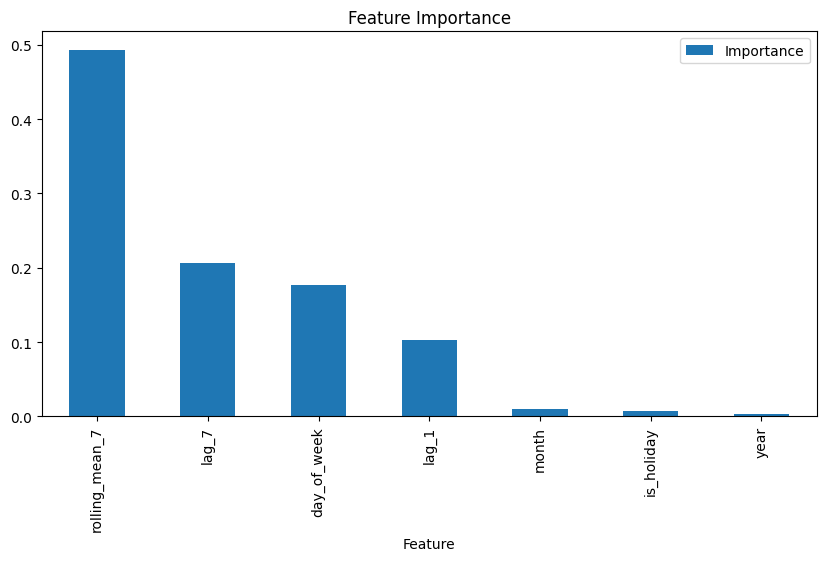

In [50]:
feature_importance.plot(
    kind = 'bar', x = 'Feature', y = 'Importance', figsize = (10, 5), title = 'Feature Importance'
    )

## Business Insights & Recommendations
Key Insights:
* Retail sales show a clear upward yearly trend, indicating overall business growth over time.
* Sales demonstrate strong weekly seasonality, with weekends consistently generating higher demand than weekdays.
* December experiences significantly higher sales volumes compared to other months, suggesting strong holiday-driven purchasing behavior.
* Lag-based features such as previous day sales and previous week sales were among the strongest predictors of future demand.
* Gradient Boosting significantly outperformed Linear Regression, reducing forecasting error and capturing more complex sales patterns.

Business Recommendations:
* Increase inventory and staffing during high-demand periods such as weekends and the December holiday season.
* Use forecasting models to improve inventory planning and reduce stock shortages during demand spikes.
* Monitor unusual sales anomalies separately, as sudden spikes remain difficult for baseline forecasting models to predict accurately.
* Continue improving forecasting accuracy by incorporating additional external factors such as promotions, marketing campaigns, and economic indicators.